# Dropout autoencoder on MNIST — entrenamiento, guardado y visualizaciones

Esta notebook implementa de punta a punta:

- entrenamiento reproducible en GPU de un autoencoder de una capa oculta sobre MNIST
- dos corridas separadas: **sin dropout** y **con dropout p=0.5**
- guardado de artefactos en `runs/autoencoder/hash_de_corrida/model_name/`
- guardado de `metrics.json` con hiperparámetros y resultados
- funciones desacopladas que reciben **un solo path de modelo** y generan:
  - visualización de **coadaptation** (mosaico de features aprendidas)
  - visualización de **representational sparsity** siguiendo el procedimiento del paper

La parte de sparsity replica el procedimiento descrito por Srivastava et al.: se toma **un minibatch aleatorio del test set**, se computan las activaciones ocultas de ese minibatch, y se grafican dos histogramas: **(1)** media de activación por unidad oculta sobre el minibatch y **(2)** todas las activaciones del mismo minibatch.

In [64]:
# =========================
# 0) Reproducibilidad fuerte
# =========================

import os
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
os.environ.setdefault('PYTHONHASHSEED', '1234')

import random
import math
import json
import time
import hashlib
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Any, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from matplotlib.colors import LinearSegmentedColormap



def seed_everything(seed: int = 1234, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


SEED = 1234
seed_everything(SEED, deterministic=False)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE =', DEVICE)
print('torch version =', torch.__version__)
if torch.cuda.is_available():
    print('cuda device =', torch.cuda.get_device_name(0))


DEVICE = cuda
torch version = 2.6.0+cu124
cuda device = NVIDIA GeForce MX230


In [65]:
# =========================
# 1) Configuración general
# =========================

ROOT_RUNS = Path('runs') / 'autoencoder'
ROOT_RUNS.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = Path.cwd().resolve()

def resolve_project_path(path_like: str | Path, project_root: str | Path | None = None) -> Path:
    root = Path(project_root).expanduser().resolve() if project_root is not None else PROJECT_ROOT
    path = Path(path_like).expanduser()
    if not path.is_absolute():
        path = (root / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"No existe el path: {path}")
    return path

@dataclass
class RunConfig:
    seed: int = 1234
    dataset_name: str = 'MNIST'
    model_type: str = 'baseline'   # baseline | dropout | dropconnect | boostdropout
    model_name: str = 'baseline'

    input_dim: int = 28 * 28
    hidden_dim: int = 256
    hidden_activation: str = 'relu'
    output_activation: str = 'sigmoid'

    # regular dropout
    dropout_p: float = 0.0

    # dropconnect
    dropconnect_p: float = 0.5

    # boostdropout
    boost_p: float = 0.5
    boost_lambd: float = 0.6
    mask_normalization: bool = False

    # train
    batch_size: int = 512
    epochs: int = 60
    learning_rate: float = 1e-3
    optimizer: str = 'Adam'
    loss_name: str = 'BCE'
    weight_decay: float = 0.0
    use_nesterov: bool = False
    num_workers: int = 4
    pin_memory: bool = True
    save_every_epoch: bool = False

def stable_run_hash(config: RunConfig, extra: Optional[Dict[str, Any]] = None) -> str:
    payload = asdict(config).copy()
    if extra is not None:
        payload['extra'] = extra
    encoded = json.dumps(payload, sort_keys=True, ensure_ascii=True).encode('utf-8')
    return hashlib.sha256(encoded).hexdigest()[:12]


In [66]:
# =========================
# 2) Datos MNIST
# =========================

transform = transforms.Compose([
    transforms.ToTensor(),
])


def build_datasets(data_root: str = './data'):
    train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)
    return train_ds, test_ds


def build_dataloaders(
    batch_size: int = 512,
    test_batch_size: Optional[int] = None,
    num_workers: int = 0,
    pin_memory: bool = True,
):
    train_ds, test_ds = build_datasets()

    if test_batch_size is None:
        test_batch_size = batch_size

    persistent_workers = num_workers > 0

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=test_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
    )
    return train_loader, test_loader


train_loader, test_loader = build_dataloaders(batch_size=512)
print('train batches =', len(train_loader), '| test batches =', len(test_loader))


train batches = 118 | test batches = 20


In [67]:
# =========================
# 3) Modelos: autoencoders 784 -> 256 -> 784
# =========================

class BoostDropout(nn.Module):
    """
    Aplica una máscara de boost con probabilidad p.
    Las activaciones seleccionadas se multiplican por (1 + lambd).
    """
    def __init__(self, p=0.5, lambd=0.2, mask_normalization=False):
        super().__init__()
        assert 0 <= p <= 1, "p debe estar entre 0 y 1"
        self.p = p
        self.lambd = lambd
        self.mask_normalization = mask_normalization

    def forward(self, x):
        if not self.training or self.p == 0:
            return x

        mask = torch.ones_like(x)
        boost_positions = torch.rand_like(x) < self.p
        mask[boost_positions] = 1.0 + self.lambd

        if self.mask_normalization:
            alpha = 1.0 + self.p * self.lambd
            return x * (mask / alpha)
        return x * mask


class DropConnect(nn.Linear):
    def __init__(self, in_features, out_features, bias=True, p=0.5):
        if not (0.0 <= p < 1.0):
            raise ValueError(f"p must be in [0, 1), got {p}")
        super().__init__(in_features, out_features, bias=bias)
        self.p = p

    def forward(self, input):
        if self.training and self.p > 0.0:
            keep_prob = 1.0 - self.p
            mask = (torch.rand_like(self.weight) < keep_prob).to(self.weight.dtype)
            weight = self.weight * mask / keep_prob
        else:
            weight = self.weight
        return F.linear(input, weight, self.bias)

    def extra_repr(self):
        base = super().extra_repr()
        return f"{base}, p={self.p}"


class OneHiddenLayerAutoencoder(nn.Module):
    """
    Baseline / Dropout autoencoder.
    Mantiene la misma interfaz que el pipeline actual:
    - encode_pre_dropout
    - encode
    - decode_logits
    - decode
    - forward -> (recon, logits, h_pre_dropout)
    """
    def __init__(self, input_dim: int = 784, hidden_dim: int = 256, dropout_p: float = 0.0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.dropout_p = dropout_p

        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.dropout = nn.Dropout(p=dropout_p) if dropout_p > 0.0 else nn.Identity()
        self.decoder = nn.Linear(hidden_dim, input_dim)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.xavier_uniform_(self.decoder.weight)
        nn.init.zeros_(self.decoder.bias)

    def encode_pre_dropout(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        h = F.relu(self.encoder(x))
        return h

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encode_pre_dropout(x)
        h = self.dropout(h)
        return h

    def decode_logits(self, h: torch.Tensor) -> torch.Tensor:
        return self.decoder(h)

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.decode_logits(h))

    def forward(self, x: torch.Tensor):
        x = x.view(x.size(0), -1)
        h = self.encode_pre_dropout(x)
        h_reg = self.dropout(h)
        logits = self.decode_logits(h_reg)
        recon = torch.sigmoid(logits)
        return recon, logits, h


class DropConnectAutoencoder(nn.Module):
    """
    Autoencoder con DropConnect en la capa encoder.
    Mantiene la misma interfaz que el pipeline actual.
    """
    def __init__(self, input_dim: int = 784, hidden_dim: int = 256, p: float = 0.5):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.dropconnect_p = p

        self.encoder = DropConnect(input_dim, hidden_dim, p=p)
        self.decoder = nn.Linear(hidden_dim, input_dim)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')
        if self.encoder.bias is not None:
            nn.init.zeros_(self.encoder.bias)
        nn.init.xavier_uniform_(self.decoder.weight)
        nn.init.zeros_(self.decoder.bias)

    def encode_pre_dropout(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        h = F.relu(self.encoder(x))
        return h

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encode_pre_dropout(x)

    def decode_logits(self, h: torch.Tensor) -> torch.Tensor:
        return self.decoder(h)

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.decode_logits(h))

    def forward(self, x: torch.Tensor):
        x = x.view(x.size(0), -1)
        h = self.encode_pre_dropout(x)
        logits = self.decode_logits(h)
        recon = torch.sigmoid(logits)
        return recon, logits, h


class BoostDropoutAutoencoder(nn.Module):
    """
    Autoencoder con BoostDropout sobre activaciones ocultas.
    Mantiene la misma interfaz que el pipeline actual.
    """
    def __init__(self, input_dim: int = 784, hidden_dim: int = 256, p: float = 0.5, lambd: float = 0.2, mask_normalization: bool = False):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.boost_p = p
        self.boost_lambd = lambd
        self.mask_normalization = mask_normalization

        self.encoder = nn.Linear(input_dim, hidden_dim)
        self.boost_dropout = BoostDropout(
            p=p,
            lambd=lambd,
            mask_normalization=mask_normalization
        )
        self.decoder = nn.Linear(hidden_dim, input_dim)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.encoder.weight, nonlinearity='relu')
        nn.init.zeros_(self.encoder.bias)
        nn.init.xavier_uniform_(self.decoder.weight)
        nn.init.zeros_(self.decoder.bias)

    def encode_pre_dropout(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        h = F.relu(self.encoder(x))
        return h

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encode_pre_dropout(x)
        h = self.boost_dropout(h)
        return h

    def decode_logits(self, h: torch.Tensor) -> torch.Tensor:
        return self.decoder(h)

    def decode(self, h: torch.Tensor) -> torch.Tensor:
        return torch.sigmoid(self.decode_logits(h))

    def forward(self, x: torch.Tensor):
        x = x.view(x.size(0), -1)
        h = self.encode_pre_dropout(x)
        h_reg = self.boost_dropout(h)
        logits = self.decode_logits(h_reg)
        recon = torch.sigmoid(logits)
        return recon, logits, h

In [68]:
# =========================
# 4) Utilidades de entrenamiento y guardado
# =========================

def reconstruction_bce_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return F.binary_cross_entropy_with_logits(logits, target, reduction='mean')


@torch.no_grad()
def evaluate_autoencoder(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    total_bce = 0.0
    total_mse = 0.0
    total_items = 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        flat = x.view(x.size(0), -1)
        recon, logits, h = model(x)
        bce = F.binary_cross_entropy_with_logits(logits, flat, reduction='sum')
        mse = F.mse_loss(recon, flat, reduction='sum')
        total_bce += bce.item()
        total_mse += mse.item()
        total_items += x.size(0)
    return {
        'bce_per_example': total_bce / total_items,
        'mse_per_example': total_mse / total_items,
    }


def run_dir_from_config(config: RunConfig) -> Path:
    run_hash = stable_run_hash(config)
    run_dir = ROOT_RUNS / run_hash / config.model_name
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


def save_json(path: Path, payload):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


def save_checkpoint(path: Path, model: nn.Module, config: RunConfig, epoch: int, metrics):
    ckpt = {
        'model_state_dict': model.state_dict(),
        'config': asdict(config),
        'epoch': epoch,
        'metrics': metrics,
        'torch_version': torch.__version__,
    }
    torch.save(ckpt, path)

def build_model(config: RunConfig) -> nn.Module:
    model_type = config.model_type.lower()

    if model_type == 'baseline':
        return OneHiddenLayerAutoencoder(
            input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            dropout_p=0.0,
        )

    if model_type == 'dropout':
        return OneHiddenLayerAutoencoder(
            input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            dropout_p=config.dropout_p,
        )

    if model_type == 'dropconnect':
        return DropConnectAutoencoder(
            input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            p=config.dropconnect_p,
        )

    if model_type == 'boostdropout':
        return BoostDropoutAutoencoder(
            input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            p=config.boost_p,
            lambd=config.boost_lambd,
            mask_normalization=config.mask_normalization,
        )

    raise ValueError(f'model_type no soportado: {config.model_type}')


def make_optimizer(model: nn.Module, config: RunConfig):
    if config.optimizer.upper() == 'ADAM':
        return torch.optim.Adam(
            model.parameters(),
            lr=config.learning_rate,
            weight_decay=config.weight_decay,
        )
    raise ValueError(f'Optimizer no soportado: {config.optimizer}')


def train_one_model(config: RunConfig) -> Path:
    seed_everything(config.seed, deterministic=False)
    run_dir = run_dir_from_config(config)
    model_path = run_dir / 'model.pt'
    metrics_path = run_dir / 'metrics.json'
    history_path = run_dir / 'history.json'

    train_loader, test_loader = build_dataloaders(
        batch_size=config.batch_size,
        num_workers=config.num_workers,
        pin_memory=config.pin_memory,
    )

    model = build_model(config).to(DEVICE)

    optimizer = make_optimizer(model, config)
    history = []
    t0 = time.time()

    for epoch in range(1, config.epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_items = 0
        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            flat = x.view(x.size(0), -1)
            optimizer.zero_grad(set_to_none=True)
            recon, logits, h = model(x)
            loss = reconstruction_bce_loss(logits, flat)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
            epoch_items += x.size(0)

        train_bce = epoch_loss / epoch_items
        row = {'epoch': epoch, 'train_bce_epoch': train_bce}

        should_eval = (epoch == 1) or (epoch % 10 == 0) or (epoch == config.epochs)
        if should_eval:
            eval_train = evaluate_autoencoder(model, train_loader, DEVICE)
            eval_test = evaluate_autoencoder(model, test_loader, DEVICE)
            row.update({
                'train_bce_eval': eval_train['bce_per_example'],
                'train_mse_eval': eval_train['mse_per_example'],
                'test_bce_eval': eval_test['bce_per_example'],
                'test_mse_eval': eval_test['mse_per_example'],
            })
            print(f"[{config.model_name}] epoch={epoch:03d} train_bce={train_bce:.4f} test_bce={eval_test['bce_per_example']:.4f} test_mse={eval_test['mse_per_example']:.4f}")
        history.append(row)
        if config.save_every_epoch:
            save_checkpoint(run_dir / f'model_epoch_{epoch:03d}.pt', model, config, epoch, row)

    total_seconds = time.time() - t0
    last_eval_row = next(row for row in reversed(history) if 'test_bce_eval' in row)
    final_metrics = {
        'train_bce_per_example': last_eval_row['train_bce_eval'],
        'train_mse_per_example': last_eval_row['train_mse_eval'],
        'test_bce_per_example': last_eval_row['test_bce_eval'],
        'test_mse_per_example': last_eval_row['test_mse_eval'],
        'training_seconds': total_seconds,
        'device': str(DEVICE),
    }

    save_checkpoint(model_path, model, config, config.epochs, final_metrics)
    save_json(history_path, {'history': history})
    save_json(metrics_path, {
        'config': asdict(config),
        'final_metrics': final_metrics,
        'paths': {
            'model_path': str(model_path),
            'history_path': str(history_path),
        },
    })
    print(f'Guardado en: {run_dir}')
    return model_path


In [69]:
# =========================
# 5) Carga de modelo desde path
# =========================

def load_model_from_path(
    model_path: str | Path,
    map_location=None,
    project_root: str | Path | None = None,
):
    model_path = resolve_project_path(model_path, project_root=project_root)

    if map_location is None:
        map_location = DEVICE

    ckpt = torch.load(model_path, map_location=map_location, weights_only=False)
    config_dict = ckpt['config']
    config = RunConfig(**config_dict)

    model = build_model(config)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(DEVICE)
    model.eval()
    return model, config, ckpt, model_path


In [85]:
# =========================
# 6) Visualización: coadaptation
# =========================

def _build_gray_floor_cmap(gray_floor: float = 0.25):
    gray_floor = float(np.clip(gray_floor, 0.0, 1.0))
    cmap = LinearSegmentedColormap.from_list(
        'gray_floor',
        [
            (gray_floor, gray_floor, gray_floor),
            (1.0, 1.0, 1.0),
        ],
        N=256,
    ).copy()

    cmap.set_under('black')
    return cmap

def _make_weight_grid(
    weights: np.ndarray,
    n_cols: int = 16,
    image_shape=(28, 28),
    pad: int = 1,
    normalization: str = 'global_symmetric',
    pad_value: float = -1.0,
    eps: float = 1e-8,
):
    weights = np.asarray(weights, dtype=np.float32)
    n_filters = weights.shape[0]
    n_rows = math.ceil(n_filters / n_cols)
    h, w = image_shape

    # padding también en el borde exterior
    canvas_h = n_rows * h + (n_rows + 1) * pad
    canvas_w = n_cols * w + (n_cols + 1) * pad
    canvas = np.ones((canvas_h, canvas_w), dtype=np.float32) * pad_value

    if normalization == 'global_symmetric':
        scale = float(np.max(np.abs(weights)))
        if scale < eps:
            norm_weights = np.full_like(weights, 0.5, dtype=np.float32)
        else:
            norm_weights = (weights / scale + 1.0) / 2.0

    elif normalization == 'global_minmax':
        wmin = float(weights.min())
        wmax = float(weights.max())
        if (wmax - wmin) < eps:
            norm_weights = np.full_like(weights, 0.5, dtype=np.float32)
        else:
            norm_weights = (weights - wmin) / (wmax - wmin)

    elif normalization == 'per_filter':
        norm_weights = np.zeros_like(weights, dtype=np.float32)
        for i in range(n_filters):
            filt = weights[i]
            fmin = float(filt.min())
            fmax = float(filt.max())
            if (fmax - fmin) < eps:
                norm_weights[i] = 0.5
            else:
                norm_weights[i] = (filt - fmin) / (fmax - fmin)
    else:
        raise ValueError(f"normalization no soportada: {normalization}")

    norm_weights = np.clip(norm_weights, 0.0, 1.0)

    for i in range(n_filters):
        r = i // n_cols
        c = i % n_cols
        top = pad + r * (h + pad)
        left = pad + c * (w + pad)
        filt = norm_weights[i].reshape(h, w)
        canvas[top:top+h, left:left+w] = filt

    return canvas


def plot_coadaptation_from_model_path(
    model_path: str | Path,
    save_path=None,
    show: bool = True,
    figsize=(10, 10),
    project_root: str | Path | None = None,
    gray_floor: float = 0.25,
):
    model, config, ckpt, resolved_model_path = load_model_from_path(
        model_path,
        project_root=project_root,
    )

    weights = model.encoder.weight.detach().cpu().numpy()
    grid = _make_weight_grid(
        weights,
        n_cols=16,
        image_shape=(28, 28),
        pad=1,
        normalization='global_symmetric',
        pad_value=-1.0,
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(
        grid,
        cmap=_build_gray_floor_cmap(gray_floor),
        interpolation='nearest',
        vmin=0.0,
        vmax=1.0,
    )
    # ax.set_title(f"Visualización de coadaptaciones — {config.model_name}")
    ax.axis('off')

    if save_path is None:
        save_path = resolved_model_path.parent / 'coadaptation.png'
    else:
        save_path = Path(save_path)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    print('Saved:', save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


In [119]:
# =========================
# 7) Visualización: representational sparsity
# =========================

def _get_loader(split: str, batch_size: int = 512):
    train_loader, test_loader = build_dataloaders(
        batch_size=batch_size,
        test_batch_size=batch_size,
    )
    split = split.lower()
    if split == 'train':
        return train_loader
    if split == 'test':
        return test_loader
    raise ValueError("split debe ser 'train' o 'test'")


@torch.no_grad()
def _collect_hidden_activations_for_batch(
    model: nn.Module,
    split: str = 'test',
    batch_size: int = 512,
    batch_index: Optional[int] = 0,
    random_batch: bool = False,
    seed: int = 1234,
):
    # Fiel al paper:
    # - minibatch aleatorio del test set
    # - activaciones ocultas del mismo minibatch
    # - sin escalar pesos por dropout en visualización
    loader = _get_loader(split=split, batch_size=batch_size)
    batches = list(loader)
    if random_batch:
        rng = np.random.default_rng(seed)
        idx = int(rng.integers(low=0, high=len(batches)))
    else:
        idx = int(batch_index if batch_index is not None else 0)
    x, _ = batches[idx]
    x = x.to(DEVICE, non_blocking=True)
    model.eval()
    h = model.encode_pre_dropout(x)
    return h.detach().cpu()


def plot_representational_sparsity_from_model_path(
    model_path: str | Path,
    split: str = 'test',
    batch_size: int = 64,
    batch_index: Optional[int] = None,
    random_batch: bool = True,
    seed: int = 1234,
    bins_mean: int = 60,
    bins_activation: int = 80,
    activation_xlim: Optional[tuple[float, float]] = None,
    show_bin_edges: bool = True,
    hist_edgecolor: str = 'black',
    hist_linewidth: float = 0.6,
    save_path=None,
    show: bool = True,
    project_root: str | Path | None = None,
):
    model, config, ckpt, resolved_model_path = load_model_from_path(
        model_path,
        project_root=project_root,
    )

    h = _collect_hidden_activations_for_batch(
        model=model,
        split=split,
        batch_size=batch_size,
        batch_index=batch_index,
        random_batch=random_batch,
        seed=seed,
    )

    mean_per_unit = h.mean(dim=0).numpy()
    all_activations = h.reshape(-1).numpy()

    hist_kwargs = {}
    if show_bin_edges:
        hist_kwargs.update({
            'edgecolor': hist_edgecolor,
            'linewidth': hist_linewidth,
        })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(mean_per_unit, bins=bins_mean, **hist_kwargs)
    axes[0].set_title('Activación media')
    # axes[0].set_xlabel('Valor de activación')
    axes[0].set_ylabel('Total')

    axes[1].hist(all_activations, bins=bins_activation, **hist_kwargs)
    axes[1].set_title('Activación')
    # axes[1].set_xlabel('Valor de activación')
    axes[1].set_ylabel('Total')

    if activation_xlim is not None:
        axes[1].set_xlim(*activation_xlim)

    batch_desc = 'minibatch aleatorio' if random_batch else f'batch_index={batch_index}'
    # fig.suptitle(
    #     f"Esparsidad de la representación — {config.model_name} | {split} | {batch_desc} | batch_size={batch_size}",
    #     y=1.05
    # )
    fig.tight_layout()

    if save_path is None:
        save_path = resolved_model_path.parent / 'sparsity.png'
    else:
        save_path = Path(save_path)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    print('Saved:', save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary = {
        'mean_activation_mean': float(mean_per_unit.mean()),
        'mean_activation_std': float(mean_per_unit.std()),
        'all_activation_mean': float(all_activations.mean()),
        'all_activation_std': float(all_activations.std()),
        'fraction_exact_zero': float((all_activations == 0.0).mean()),
        'fraction_gt_1': float((all_activations > 1.0).mean()),
        'fraction_gt_2': float((all_activations > 2.0).mean()),
    }
    print(json.dumps(summary, indent=2))
    return fig, summary


def plot_first_layer_parameter_sparsity_from_model_path(
    model_path: str | Path,
    save_path=None,
    show: bool = True,
    zero_threshold: float = 1e-3,
    bins: int = 100,
    figsize=(12, 5),
    project_root: str | Path | None = None,
    hist_xlim: tuple[float, float] | None = None,
    edgecolor: str = 'black',
    linewidth: float = 0.6,
):
    """
    Visualiza la parameter sparsity de la primera capa (encoder.weight)
    cargando el modelo desde model_path.

    Genera dos paneles:
    1) histograma de |weights|
    2) barra con proporción de pesos |w| < zero_threshold
    """
    model, config, ckpt, resolved_model_path = load_model_from_path(
        model_path,
        project_root=project_root,
    )

    if not hasattr(model, "encoder") or not hasattr(model.encoder, "weight"):
        raise ValueError(
            "El modelo no tiene encoder.weight; no se puede graficar la parameter sparsity."
        )

    weights = model.encoder.weight.detach().cpu().numpy().ravel()
    abs_weights = np.abs(weights)

    near_zero_fraction = float((abs_weights < zero_threshold).mean())
    non_zero_fraction = 1.0 - near_zero_fraction

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Panel 1: histograma de |weights|
    axes[0].hist(
        abs_weights,
        bins=bins,
        edgecolor=edgecolor,
        linewidth=linewidth,
    )
    axes[0].set_title("First-layer |weight| distribution")
    axes[0].set_xlabel("|Weight|")
    axes[0].set_ylabel("Count")

    if hist_xlim is not None:
        axes[0].set_xlim(hist_xlim)

    # Panel 2: barra de sparsity
    axes[1].bar(
        ["|w| < threshold", "|w| >= threshold"],
        [near_zero_fraction, non_zero_fraction],
    )
    axes[1].set_ylim(0, 1)
    axes[1].set_title("First-layer parameter sparsity")
    axes[1].set_ylabel("Fraction of weights")

    model_name = getattr(config, "model_name", "unknown_model")
    fig.suptitle(
        f"{model_name} | threshold={zero_threshold} | near-zero fraction={near_zero_fraction:.4f}",
        y=1.02,
    )
    fig.tight_layout()

    if save_path is None:
        save_path = resolved_model_path.parent / "first_layer_parameter_sparsity.png"
    else:
        save_path = Path(save_path)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=160, bbox_inches="tight")
    print("Saved:", save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary = {
        "zero_threshold": float(zero_threshold),
        "near_zero_fraction": near_zero_fraction,
        "non_zero_fraction": non_zero_fraction,
        "abs_weight_mean": float(abs_weights.mean()),
        "abs_weight_std": float(abs_weights.std()),
        "abs_weight_max": float(abs_weights.max()),
    }
    print(json.dumps(summary, indent=2))

    return fig, summary


# =========================
# 7b) Visualización: single-latent decodes
# =========================

@torch.no_grad()
def _get_single_latent_activation_values(
    model: nn.Module,
    split: str = 'test',
    batch_size: int = 64,
    batch_index: Optional[int] = None,
    random_batch: bool = True,
    seed: int = 1234,
    mode: str = 'quantile',
    quantile: float = 0.95,
):
    """
    Estima cuánto activar cada neurona latente cuando la encendemos sola.

    mode:
      - 'quantile': usa el cuantil por neurona (recomendado)
      - 'mean': usa la media por neurona
      - 'max': usa el máximo por neurona
    """
    h = _collect_hidden_activations_for_batch(
        model=model,
        split=split,
        batch_size=batch_size,
        batch_index=batch_index,
        random_batch=random_batch,
        seed=seed,
    )  # [B, H], en CPU

    if mode == 'quantile':
        values = torch.quantile(h, quantile, dim=0)
        desc = f"q={quantile:.2f}"
    elif mode == 'mean':
        values = h.mean(dim=0)
        desc = "mean"
    elif mode == 'max':
        values = h.max(dim=0).values
        desc = "max"
    else:
        raise ValueError("mode debe ser 'quantile', 'mean' o 'max'")

    values = torch.clamp(values, min=0.0)
    return values.to(torch.float32), desc


@torch.no_grad()
def plot_single_latent_decodes_from_model_path(
    model_path: str | Path,
    save_path=None,
    show: bool = True,
    figsize=(10, 10),
    project_root: str | Path | None = None,
    gray_floor: float = 0.25,
    split: str = 'test',
    batch_size: int = 64,
    batch_index: Optional[int] = None,
    random_batch: bool = True,
    seed: int = 1234,
    activation_mode: str = 'quantile',
    activation_quantile: float = 0.95,
    fixed_activation_value: float | None = None,
    decode_space: str = 'sigmoid',   # 'sigmoid' o 'logits'
    subtract_zero_latent: bool = False,
    clip_percentiles: tuple[float, float] | None = (1.0, 99.0),
    n_cols: int = 16,
):
    """
    Genera una grilla donde cada imagen se obtiene activando UNA sola neurona latente.

    Recomendación:
      - decode_space='sigmoid'
      - fixed_activation_value=None
      - activation_mode='quantile'
      - activation_quantile=0.95

    Si querés ver la "contribución pura" de cada neurona:
      - decode_space='logits'
      - subtract_zero_latent=True
    """
    model, config, ckpt, resolved_model_path = load_model_from_path(
        model_path,
        project_root=project_root,
    )

    hidden_dim = getattr(config, 'hidden_dim', None)
    if hidden_dim is None:
        if hasattr(model, 'decoder') and hasattr(model.decoder, 'in_features'):
            hidden_dim = int(model.decoder.in_features)
        else:
            raise ValueError("No pude inferir hidden_dim del modelo")

    if fixed_activation_value is None:
        activation_values, activation_desc = _get_single_latent_activation_values(
            model=model,
            split=split,
            batch_size=batch_size,
            batch_index=batch_index,
            random_batch=random_batch,
            seed=seed,
            mode=activation_mode,
            quantile=activation_quantile,
        )
    else:
        activation_values = torch.full(
            (hidden_dim,),
            float(fixed_activation_value),
            dtype=torch.float32,
        )
        activation_desc = f"fixed={fixed_activation_value:g}"

    latent = torch.zeros((hidden_dim, hidden_dim), device=DEVICE, dtype=torch.float32)
    idx = torch.arange(hidden_dim, device=DEVICE)
    latent[idx, idx] = activation_values.to(DEVICE)

    if decode_space == 'sigmoid':
        decoded = model.decode(latent)           # [H, 784], en [0,1]
    elif decode_space == 'logits':
        decoded = model.decode_logits(latent)    # [H, 784], real
    else:
        raise ValueError("decode_space debe ser 'sigmoid' o 'logits'")

    if subtract_zero_latent:
        z0 = torch.zeros((1, hidden_dim), device=DEVICE, dtype=torch.float32)
        if decode_space == 'sigmoid':
            baseline = model.decode(z0)          # [1, 784]
        else:
            baseline = model.decode_logits(z0)   # [1, 784]
        decoded = decoded - baseline

    decoded = decoded.detach().cpu().numpy()     # [H, 784]

    if clip_percentiles is not None:
        lo_pct, hi_pct = clip_percentiles
        lo, hi = np.percentile(decoded, [lo_pct, hi_pct])
        if hi > lo:
            decoded = np.clip(decoded, lo, hi)

    # Si restamos baseline, o si usamos logits, conviene simétrica.
    if subtract_zero_latent or decode_space == 'logits':
        normalization = 'global_symmetric'
    else:
        normalization = 'global_minmax'

    grid = _make_weight_grid(
        decoded,
        n_cols=n_cols,
        image_shape=(28, 28),
        pad=1,
        normalization=normalization,
        pad_value=-1.0,
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(
        grid,
        cmap=_build_gray_floor_cmap(gray_floor),
        interpolation='nearest',
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_title(
        f"Single-latent decodes — {config.model_name}\n"
        f"{activation_desc} | decode_space={decode_space}"
        + (" | minus zero-latent" if subtract_zero_latent else "")
    )
    ax.axis('off')

    if save_path is None:
        save_path = resolved_model_path.parent / 'single_latent_decodes.png'
    else:
        save_path = Path(save_path)

    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=200, bbox_inches='tight')
    print('Saved:', save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    summary = {
        'hidden_dim': int(hidden_dim),
        'activation_desc': activation_desc,
        'activation_min': float(activation_values.min().item()),
        'activation_mean': float(activation_values.mean().item()),
        'activation_max': float(activation_values.max().item()),
        'decode_space': decode_space,
        'subtract_zero_latent': bool(subtract_zero_latent),
    }
    print(json.dumps(summary, indent=2))

    return fig, summary

In [72]:
# =========================
# 8) Entrenamiento secuencial: uno por vez
# =========================

baseline_config = RunConfig(
    seed=SEED,
    model_type='baseline',
    model_name='baseline',
    dropout_p=0.0,
    batch_size=512,
    epochs=60,
    learning_rate=1e-3,
    optimizer='Adam',
)

dropout_config = RunConfig(
    seed=SEED,
    model_type='dropout',
    model_name='dropout_p0_5',
    dropout_p=0.5,
    batch_size=512,
    epochs=60,
    learning_rate=1e-3,
    optimizer='Adam',
)

dropconnect_config = RunConfig(
    seed=SEED,
    model_type='dropconnect',
    model_name='dropconnect_p0_5',
    dropconnect_p=0.5,
    batch_size=512,
    epochs=60,
    learning_rate=1e-3,
    optimizer='Adam',
)

boostdropout_config = RunConfig(
    seed=SEED,
    model_type='boostdropout',
    model_name='boostdropout_p0_5_lambda0_6',
    boost_p=0.5,
    boost_lambd=0.6,
    mask_normalization=False,
    batch_size=512,
    epochs=60,
    learning_rate=1e-3,
    optimizer='Adam',
)

print('Baseline run dir :', run_dir_from_config(baseline_config))
print('Dropout run dir  :', run_dir_from_config(dropout_config))
print('BoostDropout run dir :', run_dir_from_config(boostdropout_config))
print('DropConnect run dir  :', run_dir_from_config(dropconnect_config))


Baseline run dir : runs/autoencoder/e0f6268f3568/baseline
Dropout run dir  : runs/autoencoder/049b553572fb/dropout_p0_5
BoostDropout run dir : runs/autoencoder/0b7249f502d2/boostdropout_p0_5_lambda0_6
DropConnect run dir  : runs/autoencoder/6e347eac44d8/dropconnect_p0_5


In [ ]:
# =========================
# 9) Ejecutar entrenamiento del baseline
# =========================
# Descomentar para entrenar.

baseline_model_path = train_one_model(baseline_config)
baseline_model_path


In [ ]:
# =========================
# 10) Ejecutar entrenamiento del boostDropout
# =========================
# Descomentar para entrenar DESPUÉS del baseline.
# La idea es entrenar uno por vez, no ambos a la vez.

boostdropout_model_path = train_one_model(boostdropout_config)
boostdropout_model_path


In [ ]:
# =========================
# 11) Ejecutar entrenamiento del dropout
# =========================
# Descomentar para entrenar DESPUÉS del baseline.
# La idea es entrenar uno por vez, no ambos a la vez.

dropout_model_path = train_one_model(dropout_config)
dropout_model_path

In [ ]:
# =========================
# 12) Ejecutar entrenamiento del dropconnect
# =========================
# Descomentar para entrenar DESPUÉS del baseline.
# La idea es entrenar uno por vez, no ambos a la vez.

dropconnect_model_path = train_one_model(dropconnect_config)
dropconnect_model_path

In [ ]:
# =========================
# 11) Ejemplos de paths esperados
# =========================

baseline_expected_path = run_dir_from_config(baseline_config) / 'model.pt'
dropout_expected_path = run_dir_from_config(dropout_config) / 'model.pt'
print('baseline_expected_path =', baseline_expected_path)
print('dropout_expected_path  =', dropout_expected_path)


In [ ]:
# =========================
# 12) Visualizar coadaptation para un único modelo
# =========================
# Descomentar cuando ya exista el modelo.

fig = plot_coadaptation_from_model_path(
    model_path=boostdropout_model_path,
    save_path=boostdropout_model_path.parent / 'coadaptation_lamb0_6_p0_4.png',
)


In [ ]:
# =========================
# 12) Visualizar coadaptation para un único modelo
# =========================
# Descomentar cuando ya exista el modelo.

fig = plot_coadaptation_from_model_path(
    model_path=dropconnect_model_path,
    save_path=dropconnect_model_path.parent / 'coadaptation.png',
)

In [ ]:
fig = plot_coadaptation_from_model_path(
    model_path=dropout_expected_path,
    save_path=dropout_expected_path.parent / 'coadaptation.png',
)

In [ ]:
# =========================
# 13) Visualizar sparsity para un único modelo
# =========================
# Descomentar cuando ya exista el modelo.
# Por defecto usa un minibatch aleatorio del test set, fiel al procedimiento descrito.

fig, summary = plot_representational_sparsity_from_model_path(
    model_path=boostdropout_model_path,
    split='test',
    batch_size=128,
    random_batch=True,
    seed=SEED,
    save_path=boostdropout_model_path.parent / 'sparsity.png',
)


In [ ]:
# =========================
# 14) Visualizar sparsity para dropconnect
# =========================
# Descomentar cuando ya exista el modelo.
# Por defecto usa un minibatch aleatorio del test set, fiel al procedimiento descrito.

fig, summary = plot_representational_sparsity_from_model_path(
    model_path=dropconnect_model_path,
    split='test',
    batch_size=128,
    random_batch=True,
    seed=SEED,
    save_path=dropconnect_model_path.parent / 'sparsity.png',
)

In [ ]:
fig = plot_first_layer_parameter_sparsity_from_model_path(
    model_path=boostdropout_model_path,
    save_path=boostdropout_model_path.parent / "first_layer_parameter_sparsity.png",
    zero_threshold=1e-2,
)

In [ ]:
fig = plot_first_layer_parameter_sparsity_from_model_path(
    model_path=dropconnect_model_path,
    save_path=dropconnect_model_path.parent / "first_layer_parameter_sparsity.png",
    zero_threshold=1e-2,
)

In [125]:
# =========================
# 14) Helper: generar ambas figuras para UN modelo dado
# =========================

def generate_all_figures_for_model(
    model_path: str | Path,
    project_root: str | Path | None = None,
    show: bool = True,
    gray_floor: float = 0.25,
    sparsity_batch_size: int = 64,
    activation_xlim: Optional[tuple[float, float]] = None,
    show_bin_edges: bool = True,
    hist_edgecolor: str = 'black',
    hist_linewidth: float = 0.6,
    parameter_sparsity_threshold: float = 1e-2,
    parameter_sparsity_bins: int = 100,
    parameter_sparsity_xlim: tuple[float, float] | None = None,
    single_latent_batch_size: int = 64,
    single_latent_activation_quantile: float = 0.95,
    single_latent_fixed_value: float | None = None,
    single_latent_decode_space: str = 'sigmoid',
    single_latent_subtract_zero_latent: bool = True,
):
    resolved_model_path = resolve_project_path(model_path, project_root=project_root)
    out_dir = resolved_model_path.parent

    plot_coadaptation_from_model_path(
        model_path=resolved_model_path,
        save_path=out_dir / 'coadaptation.png',
        show=show,
        project_root=project_root,
        gray_floor=gray_floor,
    )

    plot_representational_sparsity_from_model_path(
        model_path=resolved_model_path,
        split='test',
        batch_size=sparsity_batch_size,
        random_batch=True,
        seed=SEED,
        activation_xlim=activation_xlim,
        show_bin_edges=show_bin_edges,
        hist_edgecolor=hist_edgecolor,
        hist_linewidth=hist_linewidth,
        save_path=out_dir / 'sparsity.png',
        show=show,
        project_root=project_root,
    )

    plot_first_layer_parameter_sparsity_from_model_path(
        model_path=resolved_model_path,
        save_path=out_dir / 'first_layer_parameter_sparsity.png',
        show=show,
        project_root=project_root,
        zero_threshold=parameter_sparsity_threshold,
        bins=parameter_sparsity_bins,
        hist_xlim=parameter_sparsity_xlim,
        edgecolor=hist_edgecolor,
        linewidth=hist_linewidth,
    )

    plot_single_latent_decodes_from_model_path(
        model_path=resolved_model_path,
        save_path=out_dir / 'single_latent_decodes.png',
        show=show,
        project_root=project_root,
        gray_floor=gray_floor,
        split='test',
        batch_size=single_latent_batch_size,
        random_batch=True,
        seed=SEED,
        activation_mode='quantile',
        activation_quantile=single_latent_activation_quantile,
        fixed_activation_value=single_latent_fixed_value,
        decode_space=single_latent_decode_space,
        subtract_zero_latent=single_latent_subtract_zero_latent,
        clip_percentiles=(1.0, 99.0),
    )

# Uso:
# generate_all_figures_for_model(
#     baseline_expected_path,
#     sparsity_batch_size=64,
#     activation_xlim=(0.0, 6.0),
# )


In [74]:
# =========================
# 15) Utilidad opcional: ver reconstrucciones
# =========================
@torch.no_grad()
def show_reconstructions(model_path: str | Path, n: int = 8):
    model, config, ckpt = load_model_from_path(model_path)
    _, test_loader = build_dataloaders(batch_size=max(n, 8))
    x, _ = next(iter(test_loader))
    x = x.to(DEVICE)
    recon, logits, h = model(x)
    recon = recon.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, n, figsize=(1.6*n, 3.2))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i, 0], cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Input')
    axes[1, 0].set_ylabel('Recon')
    plt.suptitle(f'Reconstructions — {config.model_name}')
    plt.tight_layout()
    plt.show()

# Uso:
# show_reconstructions(dropconnect_model_path, n=10)


In [75]:
# =========================
# 16) Export rápido de resumen de corrida desde model path
# =========================

def read_metrics_from_model_path(model_path: str | Path):
    model_path = Path(model_path)
    metrics_path = model_path.parent / 'metrics.json'
    with open(metrics_path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    return payload

# Uso:
# print(json.dumps(read_metrics_from_model_path(baseline_expected_path), indent=2, ensure_ascii=False))


## Plot figures from local path

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6fa4a31ed05d/dropout_p0_5/coadaptation.png


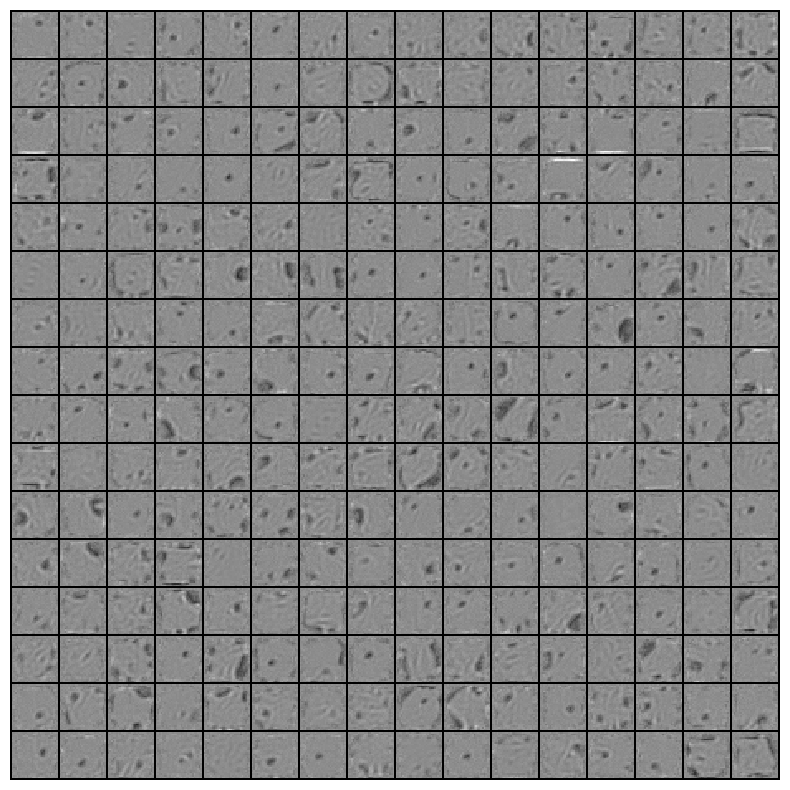

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6fa4a31ed05d/dropout_p0_5/sparsity.png


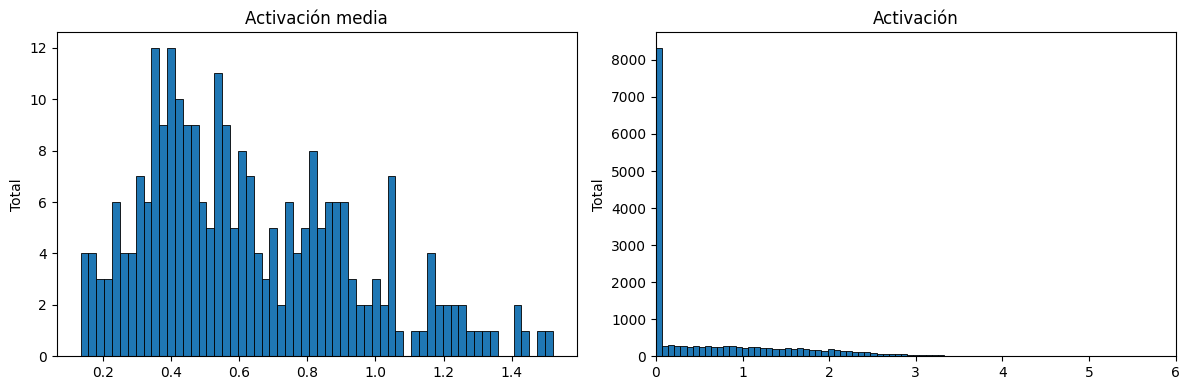

{
  "mean_activation_mean": 0.6283606290817261,
  "mean_activation_std": 0.30763742327690125,
  "all_activation_mean": 0.6283606886863708,
  "all_activation_std": 0.8610507249832153,
  "fraction_exact_zero": 0.49151611328125,
  "fraction_gt_1": 0.279296875,
  "fraction_gt_2": 0.09942626953125
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6fa4a31ed05d/dropout_p0_5/first_layer_parameter_sparsity.png


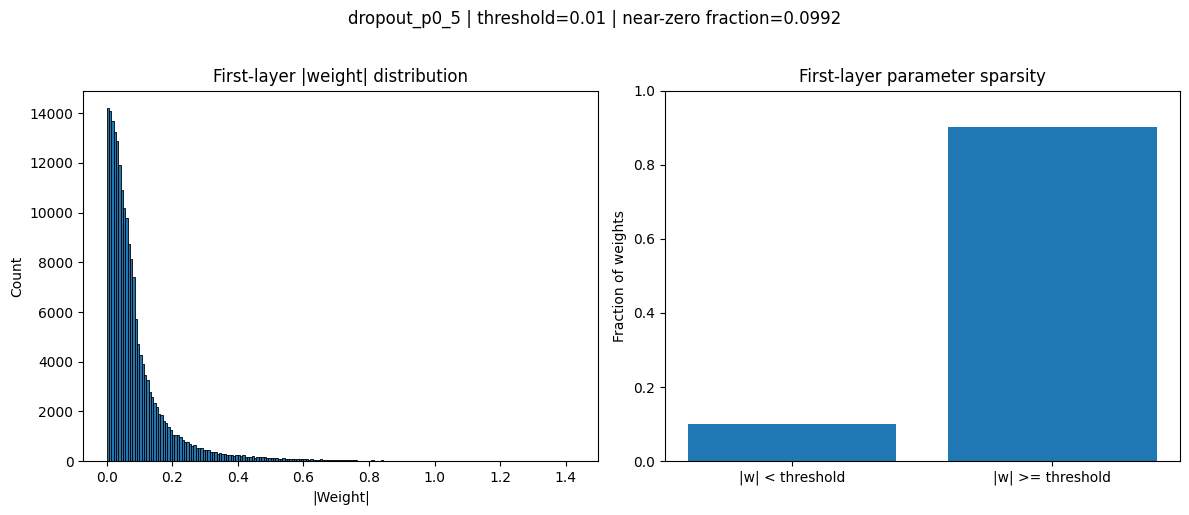

{
  "zero_threshold": 0.01,
  "near_zero_fraction": 0.09919084821428571,
  "non_zero_fraction": 0.9008091517857143,
  "abs_weight_mean": 0.09098529070615768,
  "abs_weight_std": 0.1135721430182457,
  "abs_weight_max": 1.4283556938171387
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6fa4a31ed05d/dropout_p0_5/single_latent_decodes.png


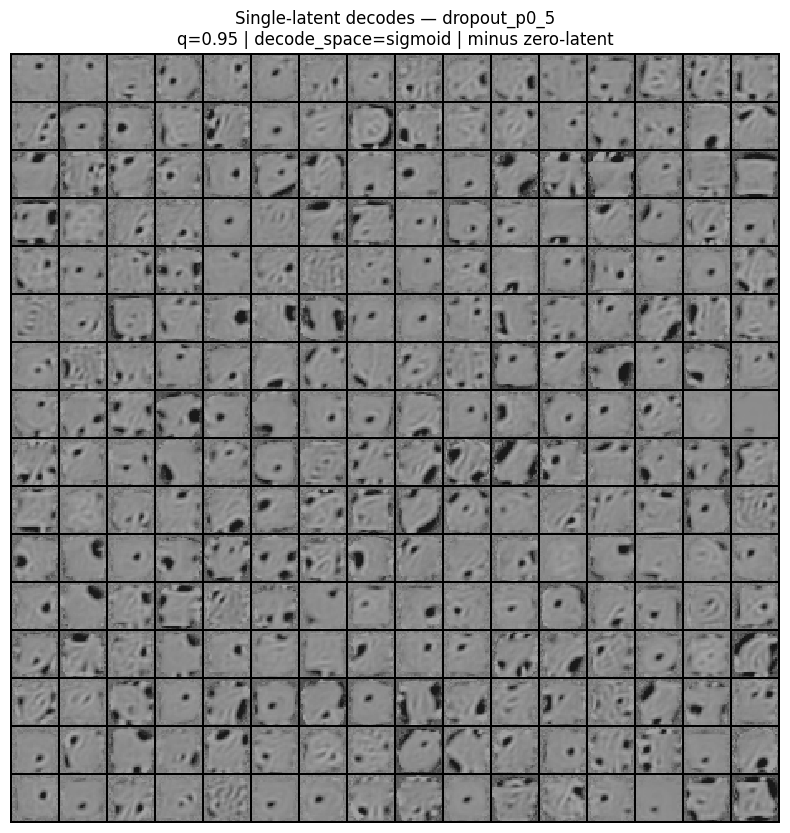

{
  "hidden_dim": 256,
  "activation_desc": "q=0.95",
  "activation_min": 0.3493778109550476,
  "activation_mean": 2.132258415222168,
  "activation_max": 3.8515191078186035,
  "decode_space": "sigmoid",
  "subtract_zero_latent": true
}


In [127]:
generate_all_figures_for_model(
    "runs/autoencoder/00 a usar?/6fa4a31ed05d/dropout_p0_5/model.pt",
    gray_floor=0.1,
    activation_xlim=(0,6),
    parameter_sparsity_bins = 200
)

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/638d7707aa98/baseline/coadaptation.png


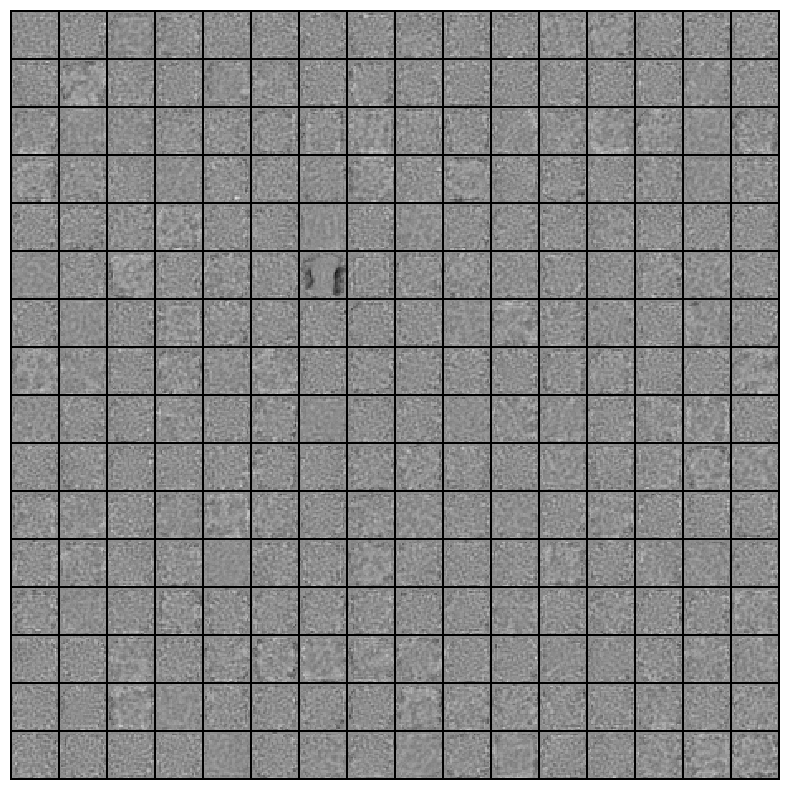

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/638d7707aa98/baseline/sparsity.png


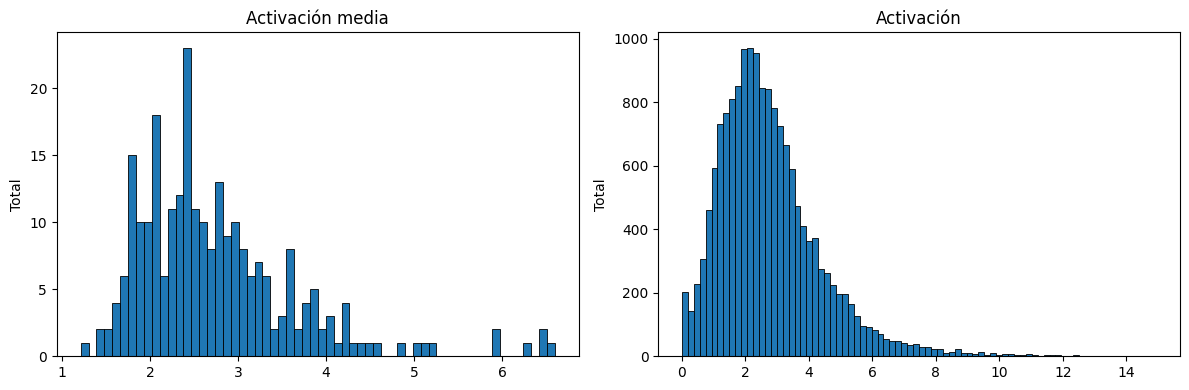

{
  "mean_activation_mean": 2.75467586517334,
  "mean_activation_std": 0.9244006276130676,
  "all_activation_mean": 2.75467586517334,
  "all_activation_std": 1.6291075944900513,
  "fraction_exact_zero": 0.00701904296875,
  "fraction_gt_1": 0.90576171875,
  "fraction_gt_2": 0.6480712890625
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/638d7707aa98/baseline/first_layer_parameter_sparsity.png


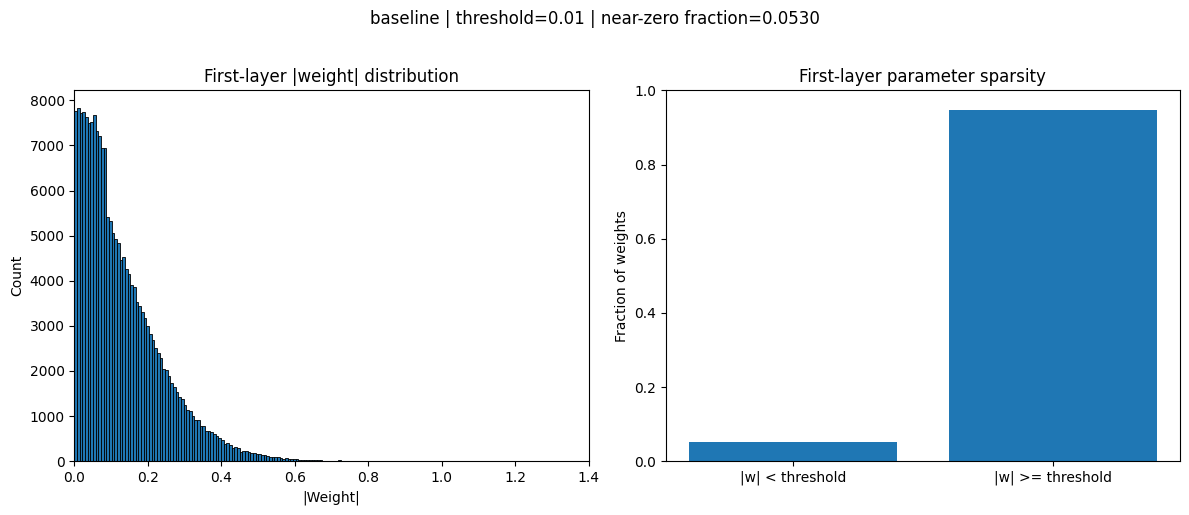

{
  "zero_threshold": 0.01,
  "near_zero_fraction": 0.052978515625,
  "non_zero_fraction": 0.947021484375,
  "abs_weight_mean": 0.1313767433166504,
  "abs_weight_std": 0.1115393340587616,
  "abs_weight_max": 1.4519591331481934
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/638d7707aa98/baseline/single_latent_decodes.png


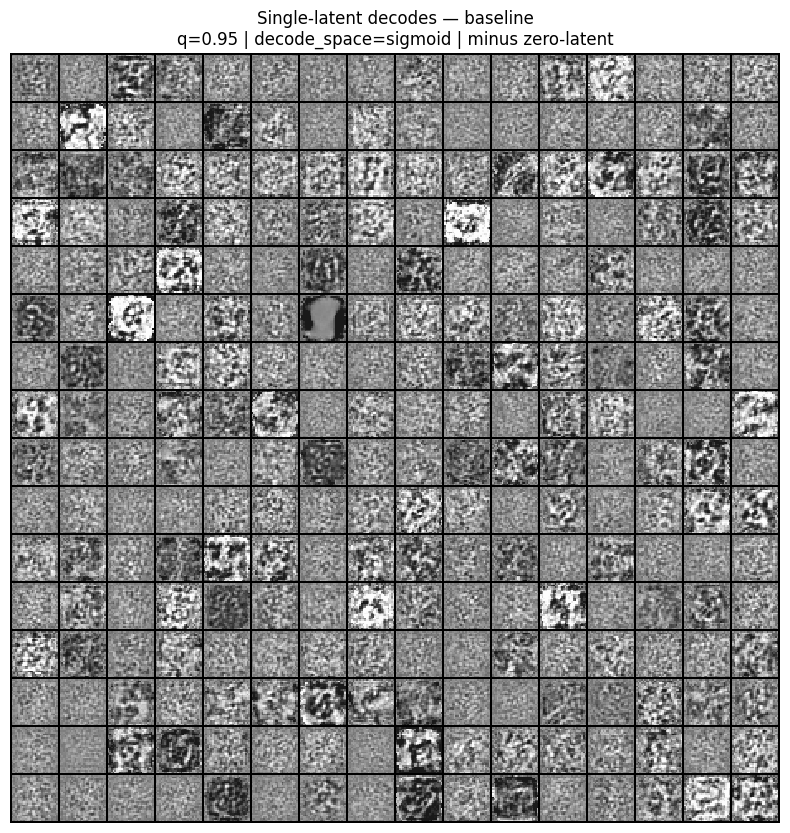

{
  "hidden_dim": 256,
  "activation_desc": "q=0.95",
  "activation_min": 2.1112515926361084,
  "activation_mean": 4.917336940765381,
  "activation_max": 12.655976295471191,
  "decode_space": "sigmoid",
  "subtract_zero_latent": true
}


In [128]:
generate_all_figures_for_model(
    "runs/autoencoder/00 a usar?/638d7707aa98/baseline/model.pt",
    gray_floor=0.1,
    parameter_sparsity_bins = 200,
    parameter_sparsity_xlim = (0.0, 1.4)

)

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6e347eac44d8/dropconnect_p0_5/coadaptation.png


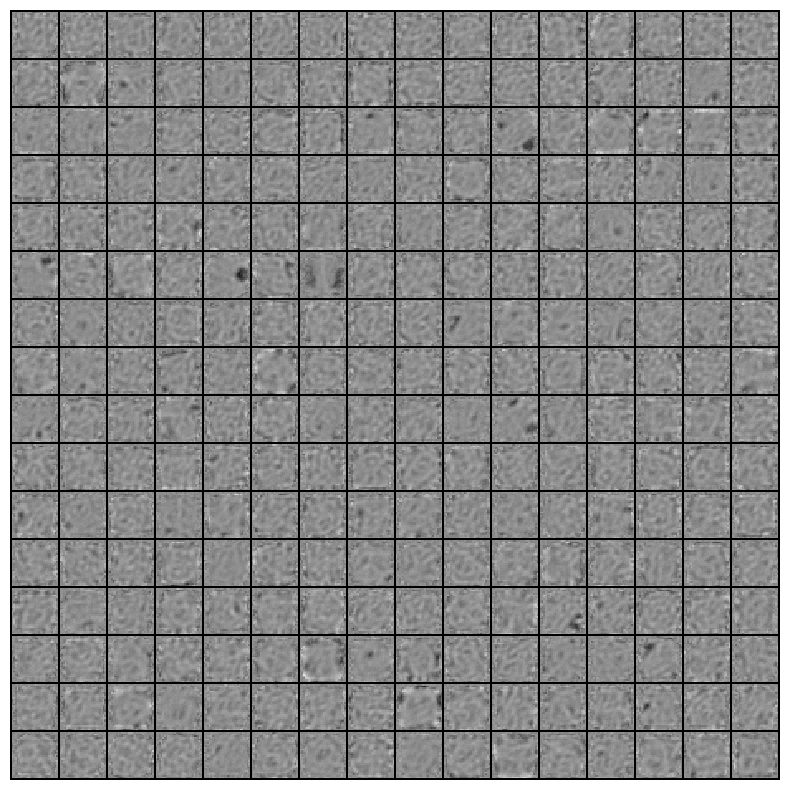

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6e347eac44d8/dropconnect_p0_5/sparsity.png


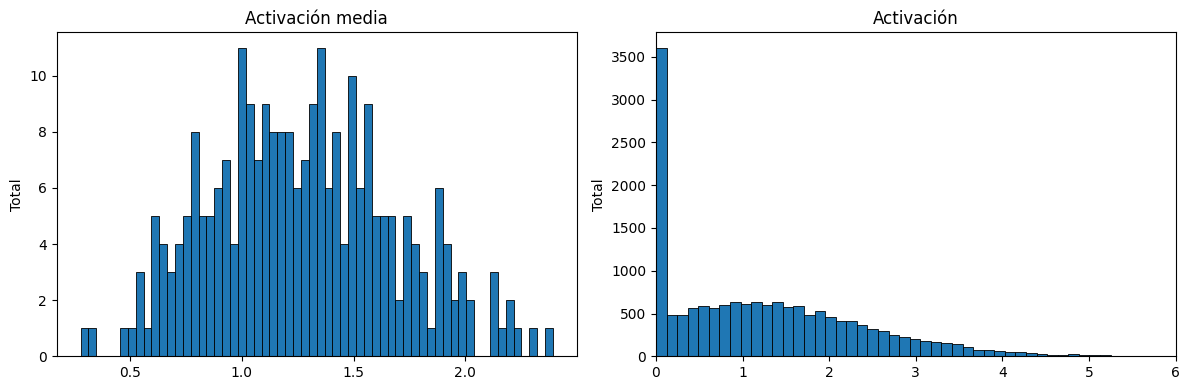

{
  "mean_activation_mean": 1.2703897953033447,
  "mean_activation_std": 0.4125536382198334,
  "all_activation_mean": 1.2703899145126343,
  "all_activation_std": 1.1272653341293335,
  "fraction_exact_zero": 0.19146728515625,
  "fraction_gt_1": 0.53253173828125,
  "fraction_gt_2": 0.24481201171875
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6e347eac44d8/dropconnect_p0_5/first_layer_parameter_sparsity.png


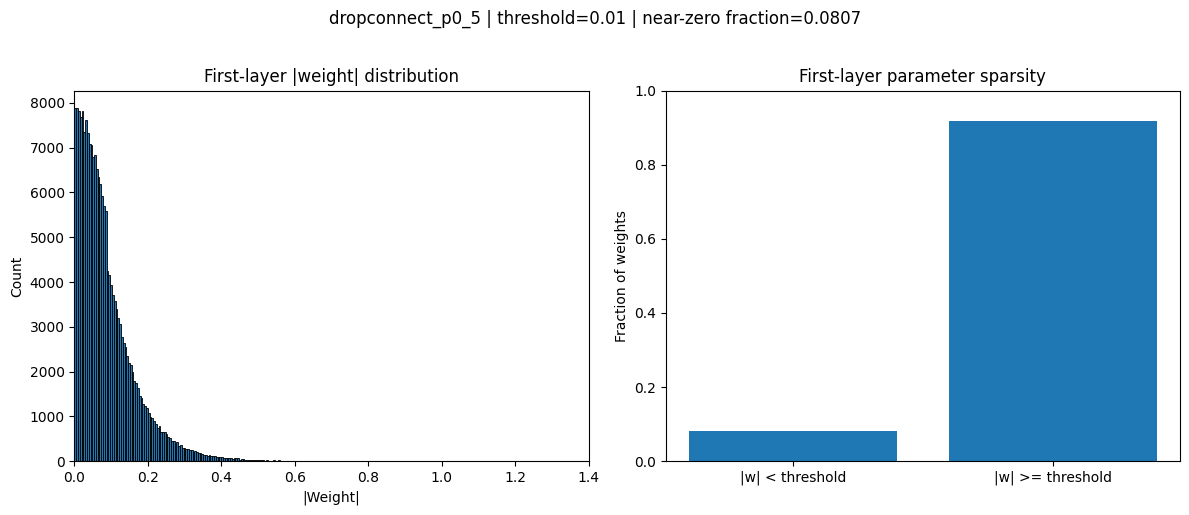

{
  "zero_threshold": 0.01,
  "near_zero_fraction": 0.08070591517857142,
  "non_zero_fraction": 0.9192940848214286,
  "abs_weight_mean": 0.08794037252664566,
  "abs_weight_std": 0.07946901023387909,
  "abs_weight_max": 0.9745992422103882
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/6e347eac44d8/dropconnect_p0_5/single_latent_decodes.png


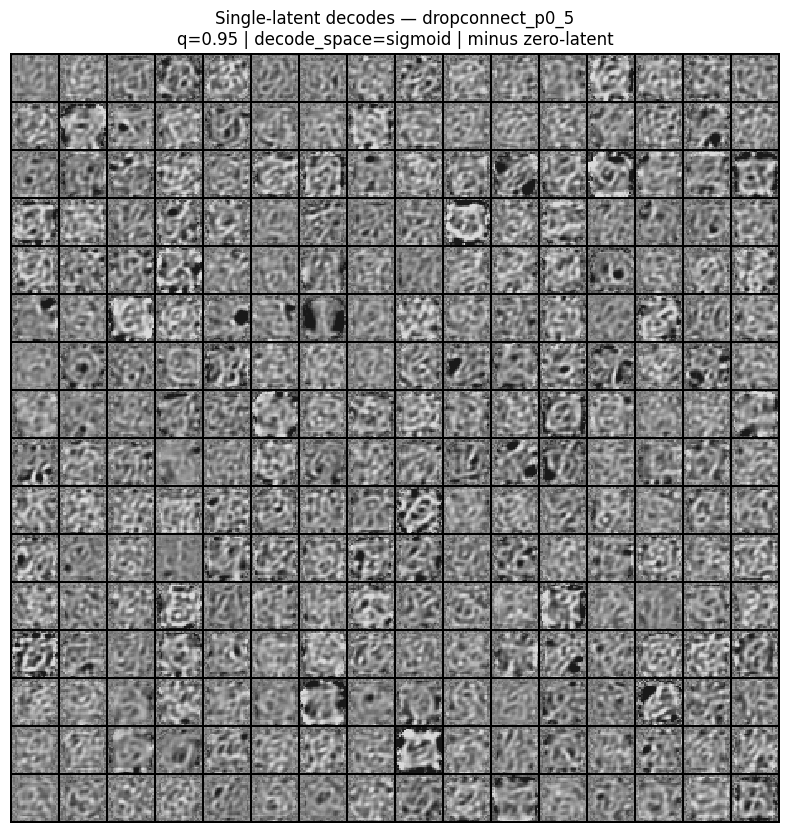

{
  "hidden_dim": 256,
  "activation_desc": "q=0.95",
  "activation_min": 1.2221239805221558,
  "activation_mean": 3.098642349243164,
  "activation_max": 6.0653910636901855,
  "decode_space": "sigmoid",
  "subtract_zero_latent": true
}


In [129]:
generate_all_figures_for_model(
    "runs/autoencoder/00 a usar?/6e347eac44d8/dropconnect_p0_5/model.pt",
    gray_floor=0.1,
    activation_xlim=(0,6),
    parameter_sparsity_bins = 200,
    parameter_sparsity_xlim = (0.0, 1.4)

)

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/aeb4f3e2f965/boostdropout_p0_7_lambda0_9/coadaptation.png


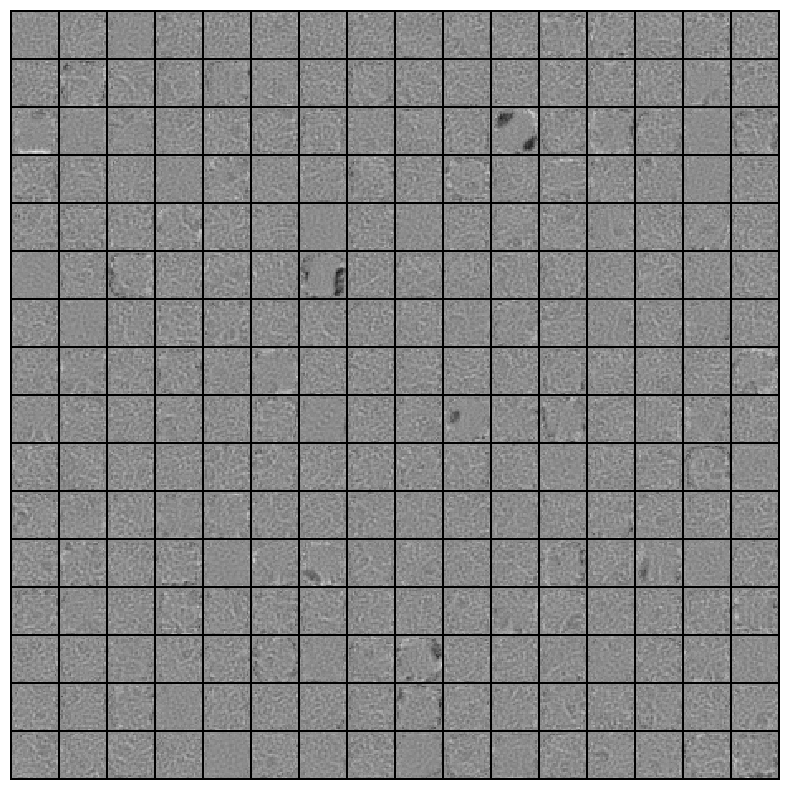

Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/aeb4f3e2f965/boostdropout_p0_7_lambda0_9/sparsity.png


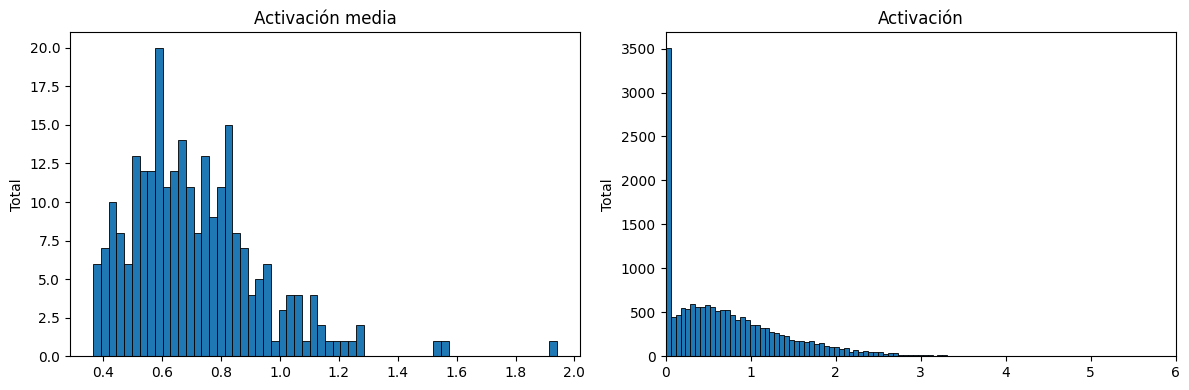

{
  "mean_activation_mean": 0.7118664979934692,
  "mean_activation_std": 0.22494879364967346,
  "all_activation_mean": 0.7118664979934692,
  "all_activation_std": 0.6804021596908569,
  "fraction_exact_zero": 0.18682861328125,
  "fraction_gt_1": 0.28271484375,
  "fraction_gt_2": 0.053955078125
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/aeb4f3e2f965/boostdropout_p0_7_lambda0_9/first_layer_parameter_sparsity.png


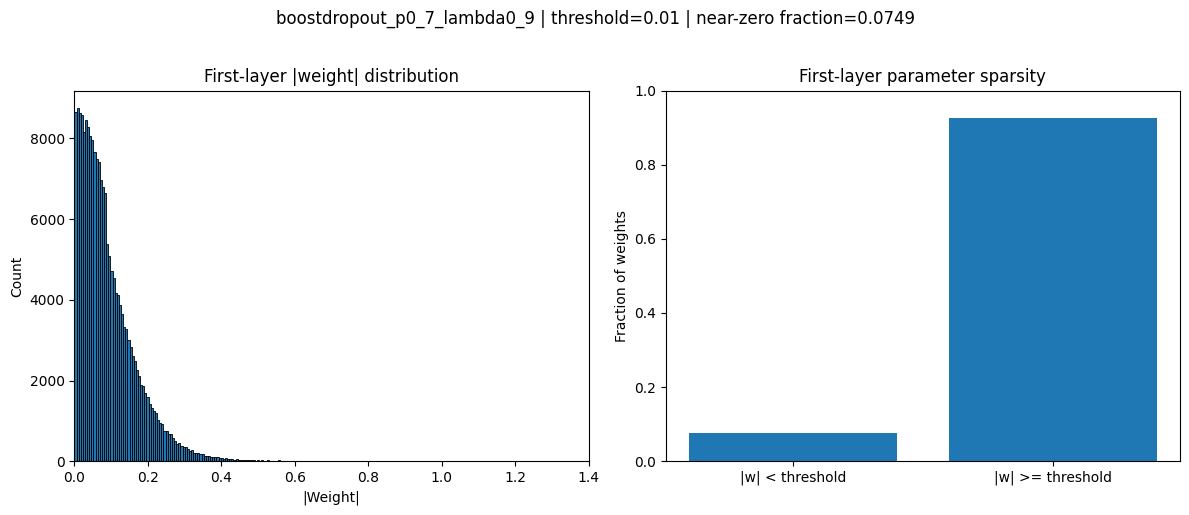

{
  "zero_threshold": 0.01,
  "near_zero_fraction": 0.07493622448979592,
  "non_zero_fraction": 0.925063775510204,
  "abs_weight_mean": 0.09109251946210861,
  "abs_weight_std": 0.07910742610692978,
  "abs_weight_max": 1.1543678045272827
}
Saved: /mnt/d2ddcf1e-b595-473f-a2bc-7304fcae012e/tes/tesis-project-repository/runs/autoencoder/00 a usar?/aeb4f3e2f965/boostdropout_p0_7_lambda0_9/single_latent_decodes.png


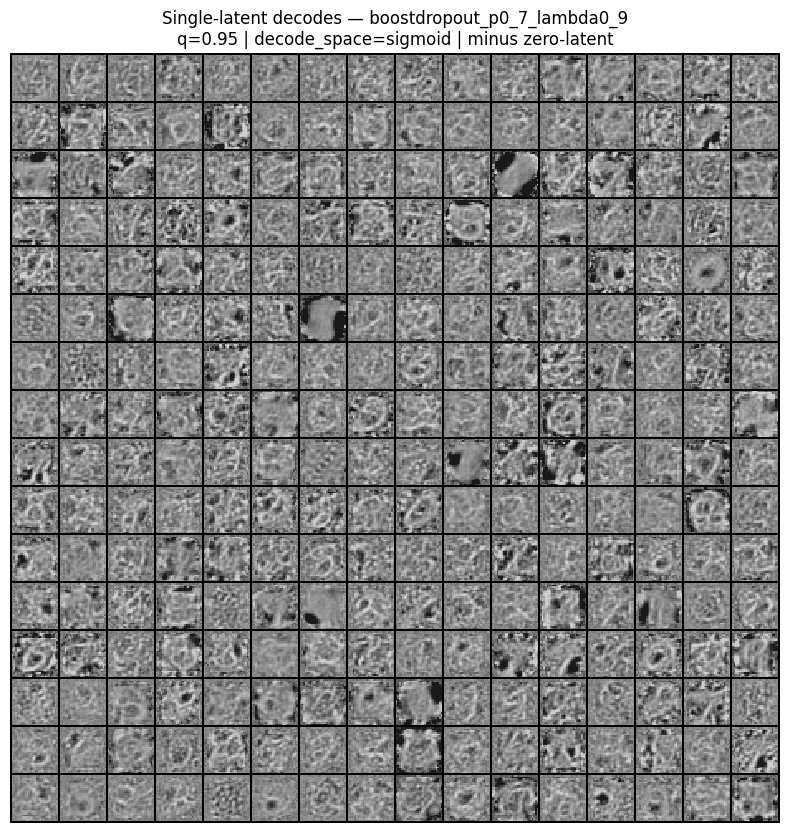

{
  "hidden_dim": 256,
  "activation_desc": "q=0.95",
  "activation_min": 0.8610970377922058,
  "activation_mean": 1.8507270812988281,
  "activation_max": 3.689541816711426,
  "decode_space": "sigmoid",
  "subtract_zero_latent": true
}


In [130]:
generate_all_figures_for_model(
    "runs/autoencoder/00 a usar?/aeb4f3e2f965/boostdropout_p0_7_lambda0_9/model.pt",
    gray_floor=0.1,
    activation_xlim=(0,6),
    parameter_sparsity_bins = 200,
    parameter_sparsity_xlim = (0.0, 1.4)

)

## Notas de fidelidad respecto del paper

- La arquitectura implementada es `784 -> 256 -> 784` con **ReLU** en la capa oculta y **dropout p=0.5** en la versión con dropout, siguiendo la descripción del paper. citeturn663853search0turn993831view2
- Para la visualización de sparsity, el paper indica que se toma **un minibatch aleatorio del test set**, y se grafican dos histogramas: **media de activación por unidad** y **activaciones** del mismo minibatch. Además, para el dropout autoencoder aclara que **no se escalan los pesos hacia abajo** al generar la figura. citeturn993831view2turn993831view3
- La visualización de “coadaptation” se implementa como mosaico de pesos del encoder, análogo a la figura de features aprendidas del paper. citeturn993831view0turn601219view0

In [131]:
m1 = build_model(RunConfig(model_type='baseline'))
m2 = build_model(RunConfig(model_type='dropout', dropout_p=0.5))
m3 = build_model(RunConfig(model_type='dropconnect', dropconnect_p=0.5))
m4 = build_model(RunConfig(model_type='boostdropout', boost_p=0.5, boost_lambd=0.6))

x = torch.randn(8, 1, 28, 28)
for m in [m1, m2, m3, m4]:
    recon, logits, h = m(x)
    print(type(m).__name__, recon.shape, logits.shape, h.shape)

OneHiddenLayerAutoencoder torch.Size([8, 784]) torch.Size([8, 784]) torch.Size([8, 256])
OneHiddenLayerAutoencoder torch.Size([8, 784]) torch.Size([8, 784]) torch.Size([8, 256])
DropConnectAutoencoder torch.Size([8, 784]) torch.Size([8, 784]) torch.Size([8, 256])
BoostDropoutAutoencoder torch.Size([8, 784]) torch.Size([8, 784]) torch.Size([8, 256])


In [160]:
# =========================
# 16) Figura comparativa de reconstrucciones (nivel tesis)
# =========================

from collections import OrderedDict
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

def _get_test_examples_by_index(indices=None, n: int = 10):
    """
    Toma ejemplos fijos del test set por índice, para que todas las filas
    usen exactamente las mismas imágenes.
    """
    _, test_ds = build_datasets()

    if indices is None:
        indices = list(range(n))
    else:
        indices = [int(i) for i in indices]
        n = len(indices)

    xs = []
    ys = []
    for idx in indices:
        x, y = test_ds[idx]
        xs.append(x)
        ys.append(y)

    x = torch.stack(xs, dim=0)   # [N, 1, 28, 28]
    y = torch.tensor(ys)
    return x, y, indices


def _make_image_strip(images: np.ndarray, pad: int = 3, pad_value: float = 1.0):
    """
    Convierte un batch de imágenes [N, 28, 28] o [N, 1, 28, 28]
    en una sola tira horizontal con padding blanco.
    """
    images = np.asarray(images, dtype=np.float32)

    if images.ndim == 4:
        images = images[:, 0]   # [N, H, W]

    n, h, w = images.shape

    canvas_h = h + 2 * pad
    canvas_w = n * w + (n + 1) * pad
    canvas = np.ones((canvas_h, canvas_w), dtype=np.float32) * pad_value

    for i in range(n):
        y0 = pad
        x0 = pad + i * (w + pad)
        canvas[y0:y0+h, x0:x0+w] = images[i]

    return canvas


@torch.no_grad()
def plot_reconstruction_comparison_figure(
    boostdropout_model_path: str | Path,
    dropout_model_path: str | Path,
    dropconnect_model_path: str | Path,
    baseline_model_path: str | Path,
    indices=None,
    n: int = 10,
    save_path=None,
    show: bool = True,
    project_root: str | Path | None = None,
    dpi: int = 220,
):
    """
    Figura de 5 filas:
      1) Inputs
      2) BoostDropout
      3) Dropout
      4) DropConnect
      5) sin regularización

    La primera fila queda separada por un pequeño espacio vertical.
    """

    # --------
    # 1) ejemplos fijos
    # --------
    x, y, used_indices = _get_test_examples_by_index(indices=indices, n=n)
    x_device = x.to(DEVICE)

    # --------
    # 2) cargar modelos y reconstruir
    # --------
    model_specs = OrderedDict([
        ("BoostDropout", boostdropout_model_path),
        ("Dropout", dropout_model_path),
        ("DropConnect", dropconnect_model_path),
        ("sin regularización", baseline_model_path),
    ])

    recon_rows = OrderedDict()

    for label, model_path in model_specs.items():
        model, config, ckpt, resolved_model_path = load_model_from_path(
            model_path,
            project_root=project_root,
        )
        recon, logits, h = model(x_device)
        recon = recon.view(-1, 1, 28, 28).detach().cpu().numpy()
        recon_rows[label] = recon

    # --------
    # 3) armar strips
    # --------
    input_strip = _make_image_strip(x.cpu().numpy(), pad=3, pad_value=1.0)
    recon_strips = {
        label: _make_image_strip(recon, pad=3, pad_value=1.0)
        for label, recon in recon_rows.items()
    }

    # --------
    # 4) figura bonita
    # --------
    fig = plt.figure(figsize=(1.15 * n + 3.2, 7.8), dpi=dpi)
    gs = GridSpec(
        nrows=6,
        ncols=1,
        height_ratios=[1.0, 0.12, 1.0, 1.0, 1.0, 1.0],
        hspace=0.08,
        figure=fig,
    )

    ax_input = fig.add_subplot(gs[0, 0])
    ax_sep = fig.add_subplot(gs[1, 0])   # fila separadora
    ax_boost = fig.add_subplot(gs[2, 0])
    ax_dropout = fig.add_subplot(gs[3, 0])
    ax_dropconnect = fig.add_subplot(gs[4, 0])
    ax_base = fig.add_subplot(gs[5, 0])
    
    axes = [ax_input, ax_boost, ax_dropout, ax_dropconnect, ax_base]

    row_labels = [
        "Input",
        "BoostDropout",
        "Dropout",
        "DropConnect",
        "sin regularización",
    ]

    row_images = [
        input_strip,
        recon_strips["BoostDropout"],
        recon_strips["Dropout"],
        recon_strips["DropConnect"],
        recon_strips["sin regularización"],
    ]

    for ax, label, row_img in zip(axes, row_labels, row_images):
        ax.imshow(row_img, cmap='gray', vmin=0.0, vmax=1.0, interpolation='nearest')
        ax.axis('off')

        ax.text(
            -0.015, 0.5, label,
            transform=ax.transAxes,
            ha='right', va='center',
            fontsize=13,
            fontweight='semibold',
        )

    # eje separador: línea horizontal centrada entre Input y BoostDropout
    ax_sep.axis('off')
    ax_sep.plot(
        [0.06, 0.94], [0.5, 0.5],
        transform=ax_sep.transAxes,
        color='black',
        linewidth=3.0,
        alpha=0.9,
        solid_capstyle='butt',
        clip_on=False,
    )

    # línea horizontal más grande y centrada entre Input y BoostDropout
    pos_input = axes[0].get_position()
    pos_boost = axes[1].get_position()
    
    y_line = 0.5 * (pos_input.y0 + pos_boost.y1)
    
    x_margin = 0.0
    x0 = max(0.0, min(pos_input.x0, pos_boost.x0) - x_margin)
    x1 = min(1.0, max(pos_input.x1, pos_boost.x1) + x_margin)
    

    # título y subtítulo
    # fig.suptitle(
    #     "Comparación de reconstrucciones en el conjunto de test",
    #     fontsize=16,
    #     fontweight='bold',
    #     y=0.985,
    # )

    # fig.text(
    #     0.5, 0.952,
    #     f"Ejemplos fijos del test set | índices: {used_indices}",
    #     ha='center',
    #     va='center',
    #     fontsize=10.5,
    # )

    # márgenes para que entren bien las etiquetas de filas
    fig.subplots_adjust(left=0.12, right=0.995, top=0.92, bottom=0.035)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=dpi)
        print("Saved:", save_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig

Saved: runs/autoencoder/reconstruction_comparison_figure.png


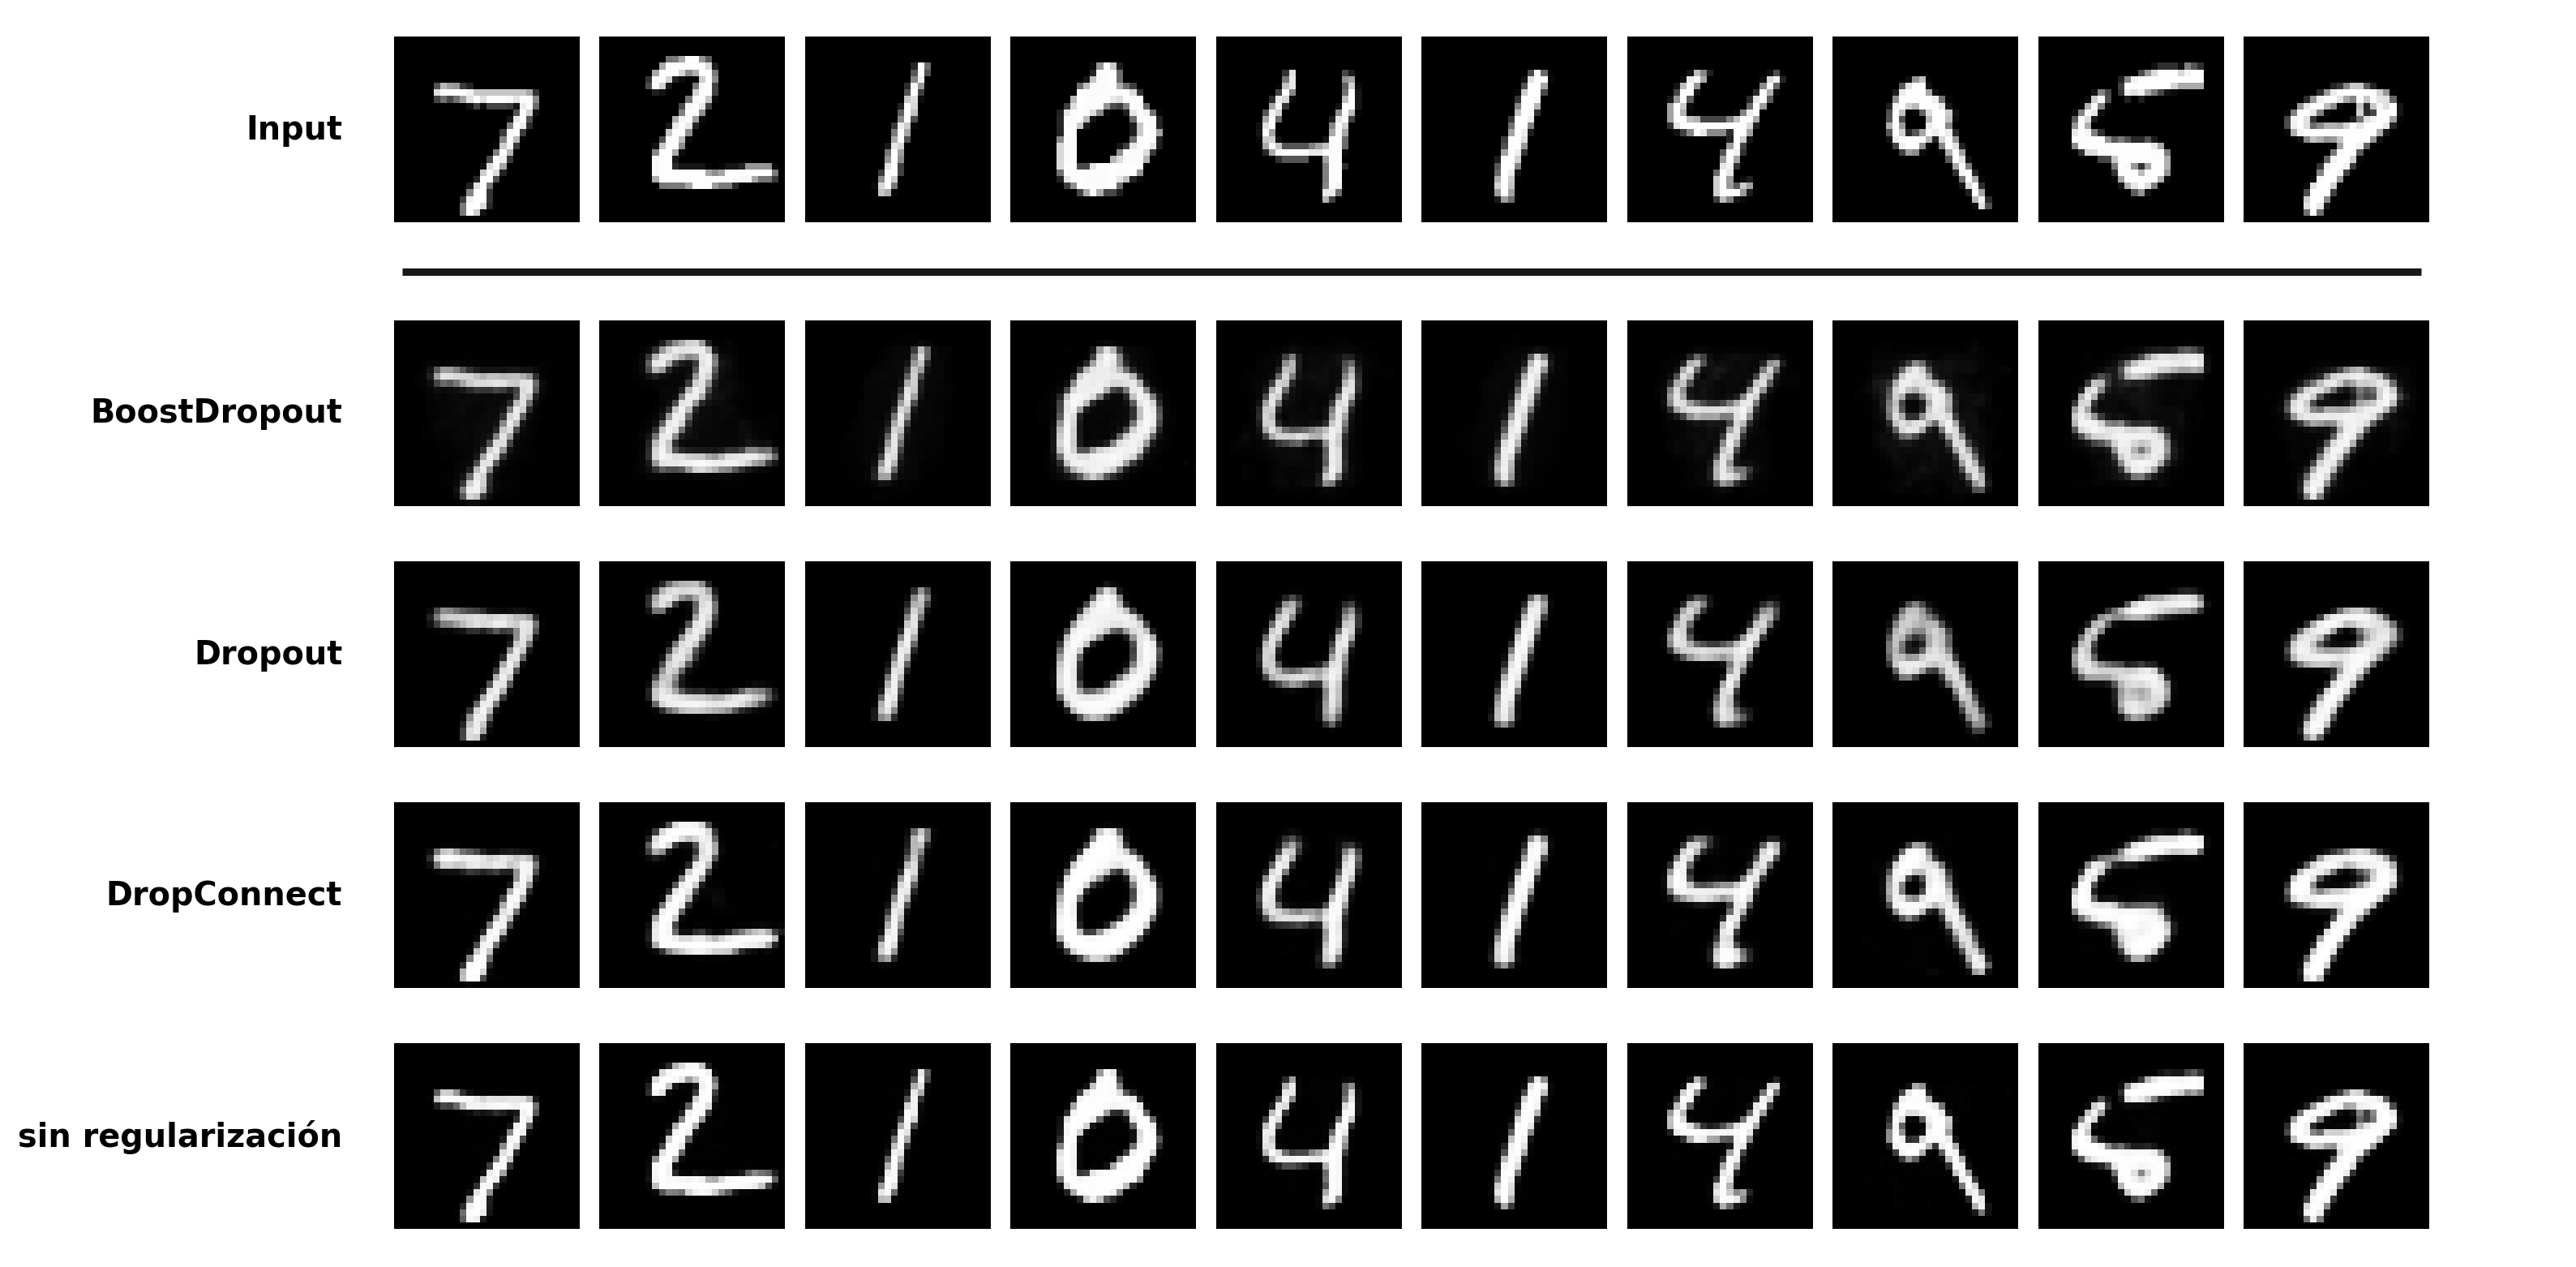

In [161]:
fig = plot_reconstruction_comparison_figure(
    boostdropout_model_path="runs/autoencoder/00 a usar?/aeb4f3e2f965/boostdropout_p0_7_lambda0_9/model.pt",
    dropout_model_path="runs/autoencoder/00 a usar?/6fa4a31ed05d/dropout_p0_5/model.pt",
    dropconnect_model_path="runs/autoencoder/00 a usar?/6e347eac44d8/dropconnect_p0_5/model.pt",
    baseline_model_path="runs/autoencoder/00 a usar?/638d7707aa98/baseline/model.pt",
    indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],  # o los que quieras
    save_path=ROOT_RUNS / "reconstruction_comparison_figure.png",
)